<a href="https://colab.research.google.com/github/nishaguptaaa/ds4400project/blob/main/DS_4400_Final_Code_Sunithi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("brfss_small.csv")
df = df.fillna(0)

df

,_MENT14D,EXERANY2,SMOKE100,SMOKDAY2,ALCDAY4,DRNK3GE5,_BMI5,GENHLTH,PHYSHLTH,INCOME3,EDUCA,EMPLOY1,MARITAL,EMTSUPRT,SDLONELY,_AGE80,_SEX,_RACE
0,1.0,1.0,2.0,0.0,0.0,0.0,2249.0,3.0,2.0,0.0,4.0,0.0,3.0,1.0,5.0,78.0,2.0,1.0
1,1.0,1.0,1.0,3.0,0.0,0.0,2583.0,1.0,0.0,11.0,6.0,0.0,1.0,1.0,5.0,80.0,1.0,1.0
2,1.0,1.0,1.0,1.0,230.0,3.0,2253.0,2.0,30.0,0.0,5.0,1.0,6.0,2.0,5.0,59.0,1.0,1.0
3,1.0,1.0,2.0,0.0,0.0,0.0,2509.0,1.0,0.0,6.0,6.0,0.0,1.0,1.0,5.0,80.0,1.0,1.0
4,1.0,2.0,2.0,0.0,0.0,0.0,1977.0,3.0,0.0,3.0,5.0,0.0,5.0,4.0,1.0,47.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449509,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,75.0,1.0,2.0
449510,2.0,2.0,1.0,1.0,230.0,0.0,2066.0,4.0,5.0,6.0,2.0,1.0,5.0,3.0,3.0,67.0,1.0,2.0
449511,1.0,2.0,2.0,0.0,202.0,0.0,2437.0,3.0,0.0,0.0,6.0,0.0,5.0,1.0,4.0,76.0,1.0,2.0
449512,1.0,1.0,1.0,3.0,0.0,0.0,2441.0,1.0,0.0,10.0,5.0,2.0,1.0,0.0,0.0,46.0,1.0,1.0


In [3]:
df = pd.read_csv("brfss_small.csv")
df = df.fillna(0)


df['stress'] = (df['_MENT14D'] >= 2).astype(int)


df = df.drop(columns=['_MENT14D'])


X = df.drop('stress', axis=1)
y = df['stress']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


trees = [10, 25, 50, 75, 100, 200]
train_results = []
test_results = []

for tree in trees:
    rf = RandomForestClassifier(n_estimators=tree, random_state=42)
    rf.fit(X_train, y_train)

    train_pred = rf.predict(X_train)
    test_pred = rf.predict(X_test)

    train_prob = rf.predict_proba(X_train)[:, 1]
    test_prob = rf.predict_proba(X_test)[:, 1]

    train_results.append({
        'Trees': tree,
        'Accuracy': accuracy_score(y_train, train_pred),
        'Precision': precision_score(y_train, train_pred),
        'Recall': recall_score(y_train, train_pred),
        'F1 Score': f1_score(y_train, train_pred),
        'AUC': roc_auc_score(y_train, train_prob)
    })

    test_results.append({
        'Trees': tree,
        'Accuracy': accuracy_score(y_test, test_pred),
        'Precision': precision_score(y_test, test_pred),
        'Recall': recall_score(y_test, test_pred),
        'F1 Score': f1_score(y_test, test_pred),
        'AUC': roc_auc_score(y_test, test_prob)
    })

print("Training Results")
print(pd.DataFrame(train_results))

print("Test Results")
print(pd.DataFrame(test_results))

Training Results
   Trees  Accuracy  Precision    Recall  F1 Score       AUC
0     10  0.979759   0.992675  0.956397  0.974199  0.998520
1     25  0.996340   0.997394  0.993437  0.995411  0.999787
2     50  0.998101   0.998807  0.996437  0.997620  0.999856
3     75  0.998404   0.998961  0.997042  0.998001  0.999872
4    100  0.998440   0.999003  0.997091  0.998046  0.999877
5    200  0.998457   0.999135  0.997000  0.998067  0.999887
Test Results
   Trees  Accuracy  Precision    Recall  F1 Score       AUC
0     10  0.695405   0.651996  0.509730  0.572152  0.738092
1     25  0.707474   0.651356  0.576376  0.611576  0.756844
2     50  0.713636   0.665819  0.568748  0.613467  0.764203
3     75  0.714303   0.661676  0.583113  0.619915  0.766788
4    100  0.715238   0.665725  0.577044  0.618220  0.768083
5    200  0.717596   0.668739  0.580997  0.621788  0.770325


In [4]:
df = pd.read_csv("brfss_small.csv")
df = df.dropna()


df['stress'] = (df['_MENT14D'] >= 2).astype(int)


print("Class distribution:", df['stress'].value_counts())


df = df.drop(columns=['_MENT14D'])


X = df.drop('stress', axis=1)
y = df['stress']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


trees = [10, 25, 50, 75, 100, 200]
test_results = []

for tree in trees:
    random_forrest = RandomForestClassifier(n_estimators=tree,
        random_state=42,
        class_weight='balanced')

    random_forrest.fit(X_train, y_train)

    test_pred = random_forrest.predict(X_test)


    if len(random_forrest.classes_) > 1:
        test_prob = random_forrest.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, test_prob)
    else:
        auc = float('nan')

    test_results.append({'Trees': tree,
        'Accuracy': accuracy_score(y_test, test_pred),
        'Precision': precision_score(y_test, test_pred, zero_division=0),
        'Recall': recall_score(y_test, test_pred, zero_division=0),
        'F1 Score': f1_score(y_test, test_pred, zero_division=0),
        'AUC': auc})


results_df = pd.DataFrame(test_results)


results_df = results_df


results_df = results_df.sort_values(by=['AUC', 'F1 Score'], ascending=False)

print("Clean Test Results:")
print(results_df.to_string(index=False))

Class distribution: stress
1    881
0    322
Name: count, dtype: int64
Clean Test Results:
 Trees  Accuracy  Precision   Recall  F1 Score      AUC
   200  0.771784   0.792271 0.931818  0.856397 0.758829
    75  0.767635   0.803030 0.903409  0.850267 0.757736
   100  0.763485   0.793103 0.914773  0.849604 0.757037
    50  0.755187   0.791045 0.903409  0.843501 0.749694
    10  0.705394   0.783784 0.823864  0.803324 0.725524
    25  0.751037   0.787129 0.903409  0.841270 0.723252


Feature Importances:
 Feature  Importance
  _AGE80    0.139356
   _BMI5    0.119727
SDLONELY    0.105906
EMTSUPRT    0.095816
 ALCDAY4    0.087952
PHYSHLTH    0.068291
DRNK3GE5    0.065756
 INCOME3    0.055679
 GENHLTH    0.053560
 MARITAL    0.043232
   EDUCA    0.040315
 EMPLOY1    0.037634
SMOKDAY2    0.025931
    _SEX    0.024680
   _RACE    0.021353
EXERANY2    0.014811
SMOKE100    0.000000


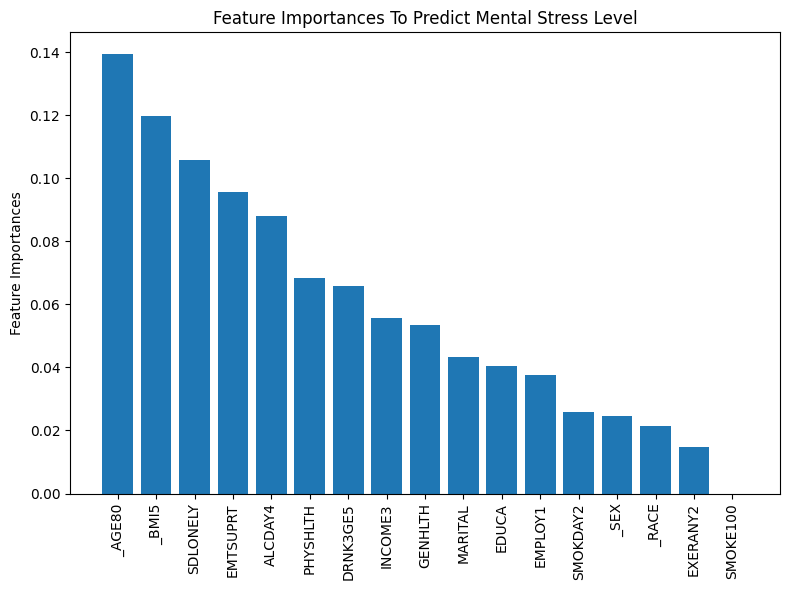

In [7]:
df = pd.read_csv("brfss_small.csv")


df = df.dropna()


df['stress'] = (df['_MENT14D'] >= 2).astype(int)


df = df.drop(columns=['_MENT14D'])


X = df.drop('stress', axis=1)
y = df['stress']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100,
    random_state=42,
    class_weight='balanced')

rf.fit(X_train, y_train)


importances = pd.Series(rf.feature_importances_, index=X.columns)


importance_df = importances.sort_values(ascending=False).reset_index()
importance_df.columns = ['Feature', 'Importance']

print("Feature Importances:")
print(importance_df.to_string(index=False))


plt.figure(figsize=(8,6))
plt.bar(importance_df['Feature'], importance_df['Importance'])
plt.title("Feature Importances To Predict Mental Stress Level")
plt.ylabel("Feature Importances")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [9]:



df = pd.read_csv("brfss_small.csv")


df = df.dropna()


threshold = df['_MENT14D'].median()
df['stress'] = (df['_MENT14D'] > threshold).astype(int)

print("Threshold used:", threshold)
print("Class distribution:", df['stress'].value_counts())


df = df.drop(columns=['_MENT14D'])

X = df.drop('stress', axis=1)
y = df['stress']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


estimators = [10, 25, 50, 75, 100, 200]
results = []

for estimator in estimators:
    gb = GradientBoostingClassifier(
        n_estimators=estimator,
        learning_rate=0.1,
        max_depth=3,
        random_state=42)

    gb.fit(X_train, y_train)

    y_pred = gb.predict(X_test)
    y_prob = gb.predict_proba(X_test)[:, 1]

    results.append({"Trees": estimator,"Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),"Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),"AUC": roc_auc_score(y_test, y_prob)})

results_df = pd.DataFrame(results)
print("Gradient Boosting Results")
print(results_df.to_string(index=False))

Threshold used: 2.0
Class distribution: stress
0    779
1    424
Name: count, dtype: int64
Gradient Boosting Results
 Trees  Accuracy  Precision   Recall       F1      AUC
    10  0.721992   0.714286 0.352941 0.472441 0.803130
    25  0.755187   0.703125 0.529412 0.604027 0.819080
    50  0.763485   0.700000 0.576471 0.632258 0.823228
    75  0.746888   0.666667 0.564706 0.611465 0.821493
   100  0.751037   0.676056 0.564706 0.615385 0.818401
   200  0.755187   0.685714 0.564706 0.619355 0.804902
